In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [295]:
#weak beam assumption, and assuming population is mostly at ground state for all time, two state atom
#linearly polarized light, D2 transitions
I_sat = 25 #W/m^2
gamma = 2*np.pi*6.0666e6 #Hz
alpha = gamma/I_sat #m^2/J

T = 308.15 #K
h = 6.62607015e-34 #m^2 kg/s
k = 1.380649e-23 #J/K
c = 2.99792458e8 #m/s
m = 1.40999344065e-25 #kg (Rb85)
mu = 72.17/100 #relative abundance of Rb85

#Rb85 absorbing frequencies from ground state F=3 only
freq2 = 3.8422905753e14 #Hz
freq3 = 3.8422912098e14 #Hz
freq4 = 3.8422924184e14 #Hz

freqs = [freq2, freq3, freq4]

In [297]:
def n():
    if T < 312.45: #solid phase
        logP = 42.57526*np.log10(T) - 94.04826-1961.258/T - 0.03771687*T
        P = 10**logP*133.322 #Pa
    else: #liquid phase
        logP = 15.88253 - 4529.635/T + 0.00058663*T - 2.99138*np.log10(T)
        P = 10**logP*133.322 #Pa

    return P*mu/(k*T) #atoms/m^3

def K(t:int, v):
    v_0 = freqs[t-2]
    sigma = v_0*np.sqrt(k*T/(m*(c**2)))
    k_0 = n()*h*v*alpha*np.sqrt(m/(2*np.pi*k*T))*(c/v_0)*(np.pi*gamma/(2*2*np.pi))
    K = k_0*np.exp((-(v-v_0)**2)/(2*(sigma**2)))
    return K


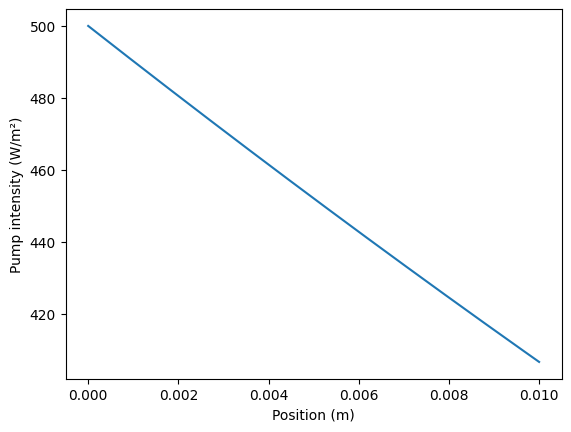

In [309]:
# --- pump beam: single frequency locked to transition ---

I_pump_0 = 500       # W/m^2, initial pump intensity
pump_transition = 4  # targeting F=3 -> F'=4

nu_pump = freqs[pump_transition - 2]          # single frequency (scalar)
K_pump_val = K(t=pump_transition, v=nu_pump)  # scalar absorption coefficient

def fun_pump(x, y):
    return [-K_pump_val * y[0] / np.sqrt(1 + 2*y[0]/I_sat)]

x_points = np.linspace(0, 0.01, 300)
solution_pump = solve_ivp(fun_pump, [0, 0.01], y0=[I_pump_0], method='RK45', t_eval=x_points)

I_pump_x = solution_pump.y[0]  # pump intensity as a function of x, for use in population ratio

plt.plot(x_points, I_pump_x)
plt.xlabel('Position (m)')
plt.ylabel('Pump intensity (W/m²)')
plt.show()

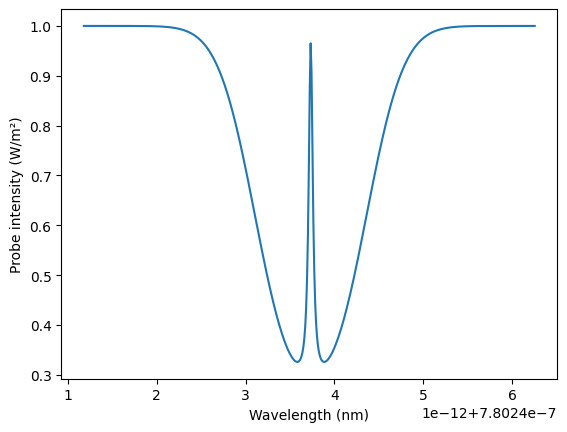

In [310]:
# --- probe beam: frequency dependent, counter-propagating ---

I_probe_0 = 1  # W/m^2, initial probe intensity (enters at x=0.05)
probe_transition = 4

f_probe = np.linspace(3.84228e14, 3.842305e14, 500)
nu_probe = freqs[probe_transition - 2]
K_probe_vals = K(t=probe_transition, v=f_probe)  # array, one value per frequency

def fun_probe(x, y):
    I_pump_at_x = np.interp(x, x_points, I_pump_x)  # pump intensity at current x
    L = 1 / (1 + (4*(f_probe - nu_probe)**2) / (gamma/(2*np.pi))**2)
    P = 1 / (1 + 2*alpha*L*I_pump_at_x/gamma)
    return K_probe_vals * P * y

# solve from x=0.05 back to x=0 (counter-propagating)
y0_probe = np.full(len(f_probe), I_probe_0)
solution_probe = solve_ivp(fun_probe, [0.01, 0], y0=y0_probe, method='RK45', t_eval=x_points[::-1])

# flip so x goes 0 -> 0.05 to match pump
I_probe_x = solution_probe.y[:, ::-1]  # shape: (500 freqs, 300 x_points)

plt.plot(c/f_probe, I_probe_x[:, 0])  # probe spectrum at x=0 (exit face)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Probe intensity (W/m²)')
plt.show()

In [311]:
import plotly.graph_objects as go

X, F = np.meshgrid(x_points, c/f_probe*1e9)

fig = go.Figure(data=[go.Surface(x=X, y=F, z=I_probe_x, colorscale='Viridis')])
fig.update_layout(scene=dict(
    xaxis_title='Position (m)',
    yaxis_title='Wavelength (nm)',
    zaxis_title='Probe intensity (W/m²)'
))
fig.show(renderer='browser')